Dataset sizes: Train 141819, Validation 30389, Test 30391
Epoch [1/100] | Loss_D: 0.5216 | Loss_G: 2.2893
Validation: Real Accuracy: 37.66%, Fake Accuracy: 96.16%
Epoch [2/100] | Loss_D: 0.4932 | Loss_G: 2.0101
Validation: Real Accuracy: 46.46%, Fake Accuracy: 80.47%
Epoch [3/100] | Loss_D: 0.4841 | Loss_G: 1.9004
Validation: Real Accuracy: 42.68%, Fake Accuracy: 99.42%
Epoch [4/100] | Loss_D: 0.4638 | Loss_G: 1.9473
Validation: Real Accuracy: 68.39%, Fake Accuracy: 91.88%
Epoch [5/100] | Loss_D: 0.4524 | Loss_G: 1.9591
Validation: Real Accuracy: 35.09%, Fake Accuracy: 97.62%
Epoch [6/100] | Loss_D: 0.4409 | Loss_G: 1.9937
Validation: Real Accuracy: 59.27%, Fake Accuracy: 87.93%
Epoch [7/100] | Loss_D: 0.4297 | Loss_G: 2.0471
Validation: Real Accuracy: 52.70%, Fake Accuracy: 99.66%
Epoch [8/100] | Loss_D: 0.4217 | Loss_G: 2.0616
Validation: Real Accuracy: 51.83%, Fake Accuracy: 98.45%
Epoch [9/100] | Loss_D: 0.4187 | Loss_G: 2.0815
Validation: Real Accuracy: 45.32%, Fake Accuracy: 98.6

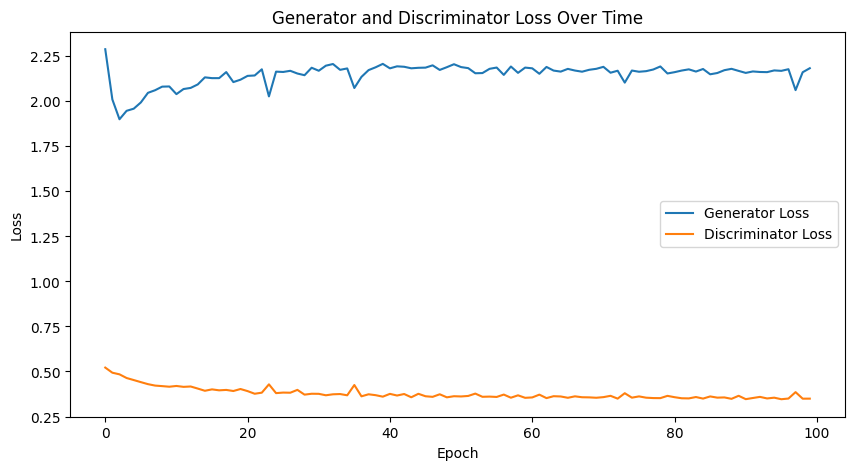

Accuracy: 0.8099
Precision: 0.9965
Recall: 0.6220
F1-Score: 0.7659


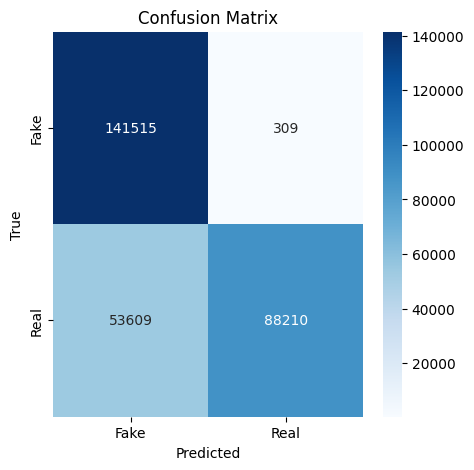

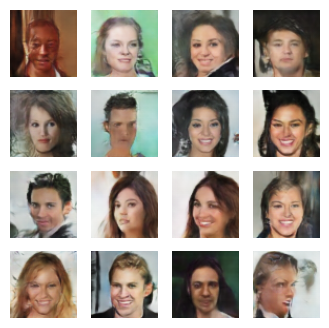

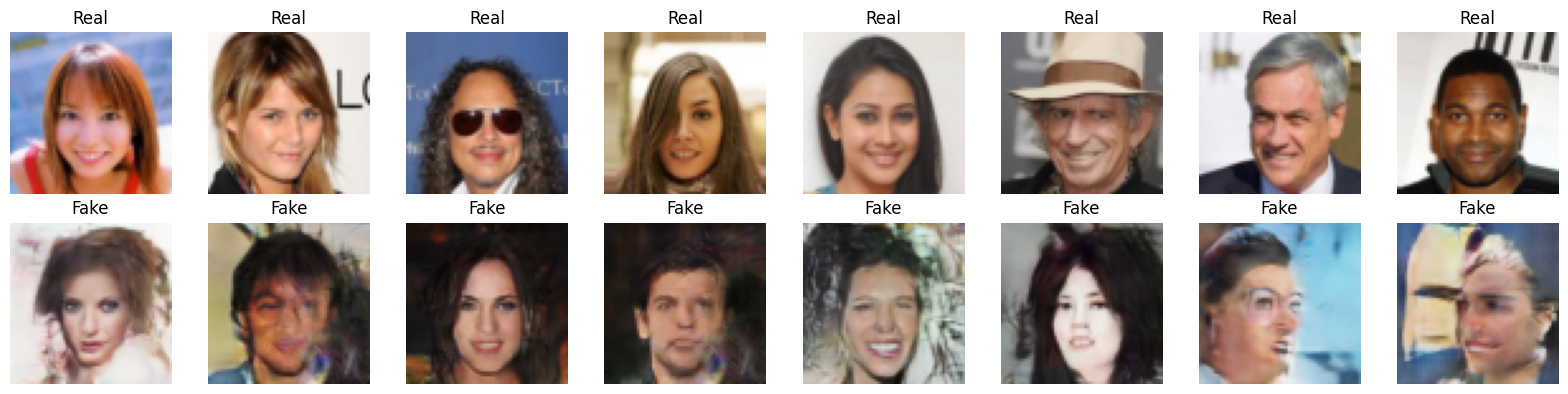

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np
from scipy.linalg import sqrtm
from torchvision.models import inception_v3
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import os

def load_data(batch_size, image_size, root_dir):
    # Transformations applied to the CelebA dataset
    transform = transforms.Compose([
        transforms.Resize(image_size),
        transforms.CenterCrop(image_size),
        transforms.ToTensor(),
        transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalizing to [-1, 1] for GANs
    ])

    # Load CelebA dataset
    dataset = datasets.ImageFolder(root_dir, transform=transform)
    
    # Split the dataset into training, validation, and testing
    total_size = len(dataset)
    train_size = int(0.7 * total_size)
    val_size = int(0.15 * total_size)
    test_size = total_size - train_size - val_size
    
    train_dataset, val_dataset, test_dataset = torch.utils.data.random_split(dataset, [train_size, val_size, test_size])

    # Create DataLoaders
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    print(f"Dataset sizes: Train {len(train_dataset)}, Validation {len(val_dataset)}, Test {len(test_dataset)}")
    
    return train_loader, val_loader, test_loader

class Generator(nn.Module):
    def __init__(self, z_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.ConvTranspose2d(z_dim, 512, 4, 1, 0, bias=False),
            nn.BatchNorm2d(512),
            nn.ReLU(True),
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.ReLU(True),
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(True),
            nn.ConvTranspose2d(128, 64, 4, 2, 1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(True),
            nn.ConvTranspose2d(64, 3, 4, 2, 1, bias=False),
            nn.Tanh()
        )

    def forward(self, x):
        return self.model(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(64, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Conv2d(512, 1, 4, 1, 0, bias=False),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.model(x).view(-1)


def train_gan(G, D, num_epochs, train_loader, val_loader, test_loader, optimizer_G, optimizer_D, criterion, z_dim, device):
    real_label_smoothing = 0.9
    fake_label_smoothing = 0.1
    
    G_losses = []
    D_losses = []

    for epoch in range(num_epochs):
        G.train()
        D.train()
        epoch_G_losses = []
        epoch_D_losses = []
        
        for i, (real_images, _) in enumerate(train_loader):
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            # Train Discriminator
            D.zero_grad()
            real_labels = torch.full((batch_size,), real_label_smoothing, device=device)
            output_real = D(real_images)
            loss_real = criterion(output_real, real_labels)

            z = torch.randn(batch_size, z_dim, 1, 1).to(device)
            fake_images = G(z)
            fake_labels = torch.full((batch_size,), fake_label_smoothing, device=device)
            output_fake = D(fake_images.detach())
            loss_fake = criterion(output_fake, fake_labels)

            loss_D = (loss_real + loss_fake) / 2
            loss_D.backward()
            optimizer_D.step()

            # Train Generator
            G.zero_grad()
            output_fake = D(fake_images)
            loss_G = criterion(output_fake, real_labels)
            loss_G.backward()
            optimizer_G.step()

            epoch_G_losses.append(loss_G.item())
            epoch_D_losses.append(loss_D.item())

        G_losses.append(sum(epoch_G_losses) / len(epoch_G_losses))
        D_losses.append(sum(epoch_D_losses) / len(epoch_D_losses))

        print(f'Epoch [{epoch + 1}/{num_epochs}] | Loss_D: {D_losses[-1]:.4f} | Loss_G: {G_losses[-1]:.4f}')
        validate(G, D, val_loader, z_dim, device)

    test(G, D, test_loader, z_dim, device)
    return G_losses, D_losses

def plot_losses(G_losses, D_losses):
    plt.figure(figsize=(10, 5))
    plt.plot(G_losses, label='Generator Loss')
    plt.plot(D_losses, label='Discriminator Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('Generator and Discriminator Loss Over Time')
    plt.show()


def validate(G, D, val_loader, z_dim, device):
    G.eval()
    D.eval()
    real_accuracy = fake_accuracy = 0
    total_real = total_fake = 0

    with torch.no_grad():
        for real_images, _ in val_loader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            real_outputs = D(real_images)
            real_predicted = (real_outputs > 0.5).float()
            real_accuracy += (real_predicted == 1).sum().item()
            total_real += batch_size

            z = torch.randn(batch_size, z_dim, 1, 1).to(device)
            fake_images = G(z)
            fake_outputs = D(fake_images)
            fake_predicted = (fake_outputs < 0.5).float()
            fake_accuracy += (fake_predicted == 1).sum().item()
            total_fake += batch_size

    real_acc = 100 * real_accuracy / total_real
    fake_acc = 100 * fake_accuracy / total_fake
    print(f'Validation: Real Accuracy: {real_acc:.2f}%, Fake Accuracy: {fake_acc:.2f}%')

def test(G, D, test_loader, z_dim, device):
    G.eval()
    D.eval()
    real_accuracy = fake_accuracy = 0
    total_real = total_fake = 0

    with torch.no_grad():
        for real_images, _ in test_loader:
            real_images = real_images.to(device)
            batch_size = real_images.size(0)

            real_outputs = D(real_images)
            real_predicted = (real_outputs > 0.5).float()
            real_accuracy += (real_predicted == 1).sum().item()
            total_real += batch_size

            z = torch.randn(batch_size, z_dim, 1, 1).to(device)
            fake_images = G(z)
            fake_outputs = D(fake_images)
            fake_predicted = (fake_outputs < 0.5).float()
            fake_accuracy += (fake_predicted == 1).sum().item()
            total_fake += batch_size

    real_acc = 100 * real_accuracy / total_real
    fake_acc = 100 * fake_accuracy / total_fake
    print(f'Testing: Real Accuracy: {real_acc:.2f}%, Fake Accuracy: {fake_acc:.2f}%')

def evaluate_discriminator(D, real_loader, G, z_dim, device):
    real_preds, real_labels = [], []
    fake_preds, fake_labels = [], []

    D.eval()
    with torch.no_grad():
        for real_images, _ in real_loader:
            real_images = real_images.to(device)
            outputs = D(real_images)
            real_preds.extend(outputs.cpu().numpy())
            real_labels.extend([1] * real_images.size(0))

        for _ in range(len(real_loader)):
            z = torch.randn(real_loader.batch_size, z_dim, 1, 1).to(device)
            fake_images = G(z)
            outputs = D(fake_images)
            fake_preds.extend(outputs.cpu().numpy())
            fake_labels.extend([0] * fake_images.size(0))

    preds = np.concatenate((real_preds, fake_preds))
    labels = np.concatenate((real_labels, fake_labels))

    preds_binary = (preds > 0.5).astype(int)
    accuracy = accuracy_score(labels, preds_binary)
    precision = precision_score(labels, preds_binary)
    recall = recall_score(labels, preds_binary)
    f1 = f1_score(labels, preds_binary)
    cm = confusion_matrix(labels, preds_binary)

    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")

    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=['Fake', 'Real'], yticklabels=['Fake', 'Real'])
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title('Confusion Matrix')
    plt.show()

def generate_images(G, z_dim, num_images, device):
    G.eval()
    z = torch.randn(num_images, z_dim, 1, 1).to(device)
    with torch.no_grad():
        fake_images = G(z)
    
    fake_images = (fake_images * 0.5 + 0.5).clamp(0, 1)
    
    grid_size = int(np.sqrt(num_images))
    plt.figure(figsize=(grid_size, grid_size))
    for i in range(num_images):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(fake_images[i].permute(1, 2, 0).cpu().numpy())
        plt.axis('off')
    plt.show()
        
def compare_real_and_fake(G, real_loader, z_dim, num_images, device):
    real_images, _ = next(iter(real_loader))
    real_images = real_images[:num_images].to(device)
    
    G.eval()
    z = torch.randn(num_images, z_dim, 1, 1).to(device)
    with torch.no_grad():
        fake_images = G(z)

    real_images = (real_images * 0.5 + 0.5).clamp(0, 1)
    fake_images = (fake_images * 0.5 + 0.5).clamp(0, 1)

    plt.figure(figsize=(2 * num_images, 4))
    
    for i in range(num_images):
        plt.subplot(2, num_images, i + 1)
        plt.imshow(real_images[i].permute(1, 2, 0).cpu().numpy())
        plt.title("Real")
        plt.axis('off')

        plt.subplot(2, num_images, num_images + i + 1)
        plt.imshow(fake_images[i].permute(1, 2, 0).cpu().numpy())
        plt.title("Fake")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()


def save_models(G, D, optimizer_G, optimizer_D, epoch, path='./saved_models'):
    """
    Save the Generator and Discriminator models, along with their optimizers and the current epoch.
    
    Args:
    G (nn.Module): Generator model
    D (nn.Module): Discriminator model
    optimizer_G (torch.optim.Optimizer): Generator optimizer
    optimizer_D (torch.optim.Optimizer): Discriminator optimizer
    epoch (int): Current epoch number
    path (str): Directory to save the models
    """
    if not os.path.exists(path):
        os.makedirs(path)
    
    torch.save({
        'epoch': epoch,
        'generator_state_dict': G.state_dict(),
        'discriminator_state_dict': D.state_dict(),
        'optimizer_G_state_dict': optimizer_G.state_dict(),
        'optimizer_D_state_dict': optimizer_D.state_dict(),
    }, os.path.join(path, f'gan_checkpoint_epoch_{epoch}.pth'))
    
    print(f"Models saved at epoch {epoch}")

def load_models(G, D, optimizer_G, optimizer_D, path):
    """
    Load the Generator and Discriminator models, along with their optimizers and the last saved epoch.
    
    Args:
    G (nn.Module): Generator model
    D (nn.Module): Discriminator model
    optimizer_G (torch.optim.Optimizer): Generator optimizer
    optimizer_D (torch.optim.Optimizer): Discriminator optimizer
    path (str): Path to the saved model file
    
    Returns:
    tuple: (Generator, Discriminator, Generator optimizer, Discriminator optimizer, epoch)
    """
    if not os.path.exists(path):
        print("No saved model found.")
        return G, D, optimizer_G, optimizer_D, 0
    
    checkpoint = torch.load(path)
    G.load_state_dict(checkpoint['generator_state_dict'])
    D.load_state_dict(checkpoint['discriminator_state_dict'])
    optimizer_G.load_state_dict(checkpoint['optimizer_G_state_dict'])
    optimizer_D.load_state_dict(checkpoint['optimizer_D_state_dict'])
    epoch = checkpoint['epoch']
    
    print(f"Models loaded from epoch {epoch}")
    return G, D, optimizer_G, optimizer_D, epoch


# Update run_all_functions to include model saving
def run_all_functions(z_dim, num_epochs, batch_size, image_size, root_dir, device, load_from_checkpoint=None):
    train_loader, val_loader, test_loader = load_data(batch_size, image_size, root_dir)

    G = Generator(z_dim).to(device)
    D = Discriminator().to(device)

    optimizer_G = optim.Adam(G.parameters(), lr=0.0002, betas=(0.5, 0.999))
    optimizer_D = optim.Adam(D.parameters(), lr=0.0002, betas=(0.5, 0.999))

    start_epoch = 0
    if load_from_checkpoint:
        G, D, optimizer_G, optimizer_D, start_epoch = load_models(G, D, optimizer_G, optimizer_D, load_from_checkpoint)
        num_epochs -= start_epoch  # Adjust remaining epochs

    criterion = nn.BCELoss()
    G_losses, D_losses = train_gan(G, D, num_epochs, train_loader, val_loader, test_loader, optimizer_G, optimizer_D, criterion, z_dim, device)
    
    # Save final models
    save_models(G, D, optimizer_G, optimizer_D, start_epoch + num_epochs)

    plot_losses(G_losses, D_losses)
    evaluate_discriminator(D, train_loader, G, z_dim, device)
    generate_images(G, z_dim, num_images=16, device=device)
    compare_real_and_fake(G, train_loader, z_dim, num_images=8, device=device)
    
z_dim = 100
num_epochs = 100
batch_size = 128
image_size = 64
root_dir = '../input/celeba-dataset/img_align_celeba'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# To start training from scratch
run_all_functions(z_dim, num_epochs, batch_size, image_size, root_dir, device)

# To resume training from a saved checkpoint
# run_all_functions(z_dim, num_epochs, batch_size, image_size, root_dir, device, load_from_checkpoint='./saved_models/gan_checkpoint_epoch_20.pth')